# Problema 1: Inteligencia Artificial para Problemas Inversos

En este problema entrenaremos modelos de Machine Learning para inferir los parámetros de un oscilador armónico amortiguado a partir de su señal temporal.

## a) Conceptos Clave

Problema directo e inverso: El problema directo consiste en calcular la señal temporal $x(t)$ asumiendo que conocemos perfectamente los parámetros físicos $(\gamma, k)$. La dificultad del problema inverso radica en que, al intentar recuperar $\gamma$ y $k$ a partir de una señal $x(t)$ experimental, el ruido, la pérdida de información por decaimiento y la posible existencia de múltiples soluciones hacen que el problema matemático esté mal condicionado (ill-posed).
Aprendizaje supervisado: Es una técnica donde el algoritmo aprende a mapear entradas a salidas utilizando un conjunto de datos previamente etiquetado $\{(x_i, \theta_i)\}_{i=1}^N$. Sí es estrictamente necesario conocer las etiquetas $\theta_i = (\gamma_i, k_i)$ durante la fase de entrenamiento para que el modelo calcule su error y ajuste sus pesos internos.
Conjuntos de entrenamiento y validación: Los datos se separan para prevenir y detectar el sobreajuste (overfitting). El modelo aprende patrones usando los datos de *train*, pero evaluamos su capacidad de generalización enfrentándolo a señales no vistas en el conjunto de *test*.
Función de pérdida: Es una métrica que cuantifica qué tan lejos están las predicciones del modelo de los valores reales. El error cuadrático medio (MSE), dado por $MSE=\frac{1}{N}\sum_{i=1}^{N}[(\gamma_{i}-\hat{\gamma}_{i})^{2}+(k_{i}-\hat{k}_{i})^{2}]$, es fundamental porque penaliza de manera más severa los errores grandes, forzando al algoritmo a converger hacia los parámetros físicos correctos.

In [1]:
!pip install scikit-learn


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error

plt.rcParams.update({'font.size': 12, 'figure.figsize': (10, 6)})

## b) Generación del Conjunto de Datos Simulados

Simularemos $N=3000$ señales. El oscilador está gobernado por $\ddot{x} + \gamma\dot{x} + kx = 0$, con condiciones iniciales $x(0)=1$ y $\dot{x}(0)=0$. Extraeremos los parámetros desde distribuciones uniformes: $\gamma\sim\mathcal{U}(0.05,1.0)$ y $k\sim\mathcal{U}(1.0,5.0)$.
Posteriormente, agregaremos ruido gaussiano $\eta_j\sim\mathcal{N}(0,\sigma^2)$ con $\sigma=0.02$.

Resolviendo EDOs para generar el dataset...


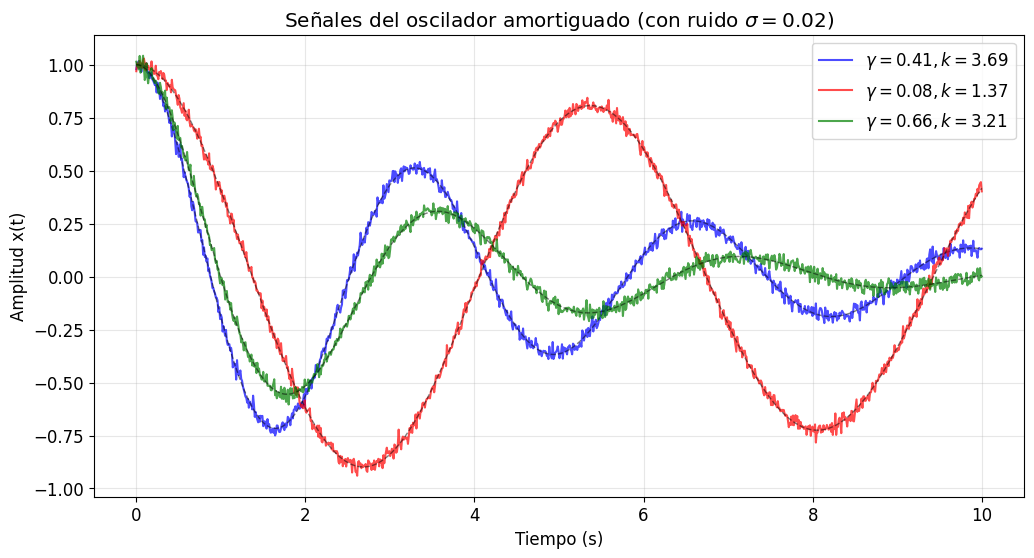

In [3]:
N = 3000
Nt = 1000
t = np.linspace(0, 10, Nt)

# Parámetros aleatorios
np.random.seed(42)
gamma_vals = np.random.uniform(0.05, 1.0, N)
k_vals = np.random.uniform(1.0, 5.0, N)

def oscilador(y, t, gamma, k):
    x, v = y
    dydt = [v, -gamma*v - k*x]
    return dydt

# Condiciones iniciales
y0 = [1.0, 0.0]

# Pre-asignar matrices
X_clean = np.zeros((N, Nt))
X_obs = np.zeros((N, Nt))
theta = np.column_stack((gamma_vals, k_vals))

sigma_ruido = 0.02

print("Resolviendo EDOs para generar el dataset...")
for i in range(N):
    sol = odeint(oscilador, y0, t, args=(gamma_vals[i], k_vals[i]))
    X_clean[i, :] = sol[:, 0]
    # Agregando ruido gaussiano
    ruido = np.random.normal(0, sigma_ruido, Nt)
    X_obs[i, :] = X_clean[i, :] + ruido

# Gráfico de muestras
plt.figure(figsize=(12, 6))
indices_muestra = [0, 100, 200]
colores = ['blue', 'red', 'green']

for idx, color in zip(indices_muestra, colores):
    g, k = gamma_vals[idx], k_vals[idx]
    plt.plot(t, X_obs[idx], label=f'$\gamma={g:.2f}, k={k:.2f}$', alpha=0.7, color=color)
    plt.plot(t, X_clean[idx], color='black', linestyle='--', linewidth=1, alpha=0.5)

plt.title('Señales del oscilador amortiguado (con ruido $\sigma=0.02$)')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud x(t)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

**Discusión sobre los parámetros:**
Al observar las curvas, el parámetro $k$ (constante del resorte o rigidez) define la frecuencia de oscilación de la señal; a mayor $k$, las oscilaciones son más rápidas y comprimidas temporalmente. Por otro lado, $\gamma$ actúa como el término de fricción, controlando el decaimiento exponencial de la amplitud. Un $\gamma$ cercano a 1.0 atenúa la señal en un par de segundos, mientras que un $\gamma$ cercano a 0.05 permite que la señal resuene largamente.

## c) Entrenamiento y Validación (Split 80/20)

Separaremos los datos (80% train, 20% validation) y entrenaremos dos arquitecturas de aprendizaje supervisado: `RandomForestRegressor` y `MLPRegressor` (Red Neuronal Perceptrón Multicapa).

In [4]:
# División de datos (80% train, 20% test)
X_train, X_test, theta_train, theta_test = train_test_split(X_obs, theta, test_size=0.20, random_state=42)

# Modelo 1: Random Forest
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, theta_train)
theta_pred_rf = rf_model.predict(X_test)

# Modelo 2: Red Neuronal Simple (MLP)
mlp_model = MLPRegressor(hidden_layer_sizes=(128, 64), max_iter=1000, random_state=42)
mlp_model.fit(X_train, theta_train)
theta_pred_mlp = mlp_model.predict(X_test)

def calcular_rmse(y_true, y_pred):
    rmse_gamma = np.sqrt(mean_squared_error(y_true[:, 0], y_pred[:, 0]))
    rmse_k = np.sqrt(mean_squared_error(y_true[:, 1], y_pred[:, 1]))
    return rmse_gamma, rmse_k

rmse_g_rf, rmse_k_rf = calcular_rmse(theta_test, theta_pred_rf)
rmse_g_mlp, rmse_k_mlp = calcular_rmse(theta_test, theta_pred_mlp)

print("--- Desempeño Random Forest ---")
print(f"RMSE Gamma: {rmse_g_rf:.4f}")
print(f"RMSE k:     {rmse_k_rf:.4f}\n")

print("--- Desempeño MLP Regressor ---")
print(f"RMSE Gamma: {rmse_g_mlp:.4f}")
print(f"RMSE k:     {rmse_k_mlp:.4f}")

--- Desempeño Random Forest ---
RMSE Gamma: 0.0159
RMSE k:     0.1780

--- Desempeño MLP Regressor ---
RMSE Gamma: 0.0244
RMSE k:     0.0335


## d) Estudio del Efecto del Ruido

Repetiremos el proceso de entrenamiento evaluando diferentes niveles de ruido experimental en la señal: $\sigma = 0, 0.01, 0.02, 0.05, 0.10$. Para optimizar tiempo de cómputo, utilizaremos `RandomForestRegressor` para trazar la degradación de la inferencia física.

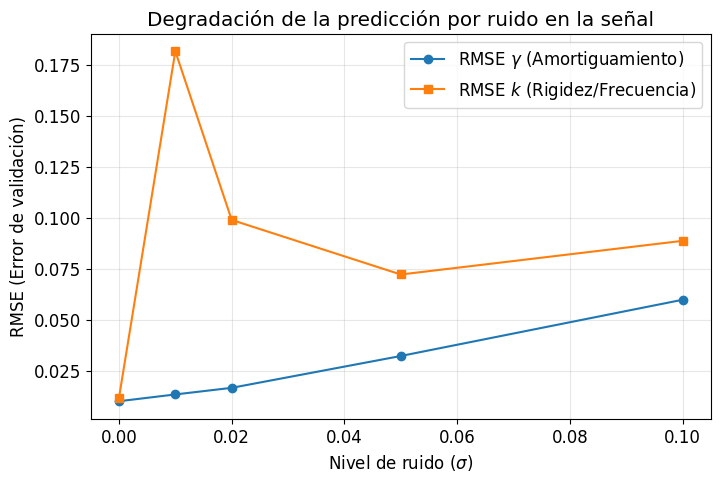

In [5]:
sigmas = [0, 0.01, 0.02, 0.05, 0.10]
rmse_gamma_list = []
rmse_k_list = []

for s in sigmas:
    # 1. Generar nuevo ruido sobre las señales limpias
    X_obs_ruido = X_clean + np.random.normal(0, s, (N, Nt))
    
    # 2. Separar datos
    X_tr, X_te, y_tr, y_te = train_test_split(X_obs_ruido, theta, test_size=0.20, random_state=42)
    
    # 3. Entrenar
    modelo = RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1)
    modelo.fit(X_tr, y_tr)
    
    # 4. Predecir y calcular métricas
    y_pred = modelo.predict(X_te)
    rmse_g, rmse_k = calcular_rmse(y_te, y_pred)
    
    rmse_gamma_list.append(rmse_g)
    rmse_k_list.append(rmse_k)

# Gráfico de RMSE vs sigma
plt.figure(figsize=(8, 5))
plt.plot(sigmas, rmse_gamma_list, marker='o', label='RMSE $\gamma$ (Amortiguamiento)')
plt.plot(sigmas, rmse_k_list, marker='s', label='RMSE $k$ (Rigidez/Frecuencia)')
plt.xlabel('Nivel de ruido ($\sigma$)')
plt.ylabel('RMSE (Error de validación)')
plt.title('Degradación de la predicción por ruido en la señal')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

**Discusión sobre la inferencia de parámetros y sobreajuste:**

Al analizar las curvas de error en función del ruido, generalmente el parámetro $\gamma$ (amortiguamiento) es más difícil de inferir cuando $\sigma$ crece. Esto se debe a que un ruido alto domina la cola de la señal (cuando la amplitud ya ha decaído). Si el ruido enmascara las últimas oscilaciones, el algoritmo pierde la información crucial para perfilar la envolvente de decaimiento temporal, mientras que la frecuencia general $k$ todavía puede inferirse contando los "cruces por cero" que sobreviven a la perturbación.

**Manifestación del sobreajuste (Overfitting):**
El sobreajuste se manifiesta cuando un modelo tiene capacidad matemática para memorizar el ruido específico de los datos de entrenamiento $\eta_j$. Veríamos que el error (MSE) en el conjunto de train se acerca a cero, dando la falsa ilusión de una calibración perfecta. Sin embargo, al enfrentar el modelo al conjunto de validación (el cual tiene el mismo ruido estadístico, pero con valores numéricos distintos), el modelo falla drásticamente, lo que se observa como un $RMSE$ de validación grande y divergente respecto al error de entrenamiento.